# 🏭 Hot Rolling Alpha Defect Detection — Elite ML Pipeline

**Target**: 100% Recall (zero false negatives) + Precision > 90%  
**Strategy**: Ensemble of LightGBM + XGBoost + CatBoost + RandomForest + ExtraTrees  
with heavy class weighting, rich feature engineering, and cross-validated threshold tuning.

---
**Setup**: Place `train.csv` and `test.csv` in the same directory as this notebook, then run all cells.

## 📦 Install Dependencies

In [1]:
!pip install lightgbm xgboost catboost scikit-learn pandas numpy --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import recall_score, precision_score, roc_auc_score

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

print('All imports OK ✅')

All imports OK ✅


## Step 1 — Load Data

In [3]:
train = pd.read_csv(r'C:\Tata AI Hackathon\Tata-AI-Hackathon\dataset\train.csv')
test  = pd.read_csv(r'C:\Tata AI Hackathon\Tata-AI-Hackathon\dataset\test.csv')

print(f'Train : {train.shape}  |  Defects: {train["Y"].sum()} / {len(train)} ({train["Y"].mean()*100:.1f}%)')
print(f'Test  : {test.shape}')

feature_cols = [c for c in train.columns if c.startswith('X')]
assert len(feature_cols) == 49, f'Expected 49 features, got {len(feature_cols)}'
print(f'Feature columns: {len(feature_cols)}')

train.head(3)

Train : (1352, 51)  |  Defects: 66.0 / 1352 (4.9%)
Test  : (339, 50)
Feature columns: 49


,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.04796,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.00000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.00000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0


## Step 2 — Feature Engineering

Three families of features:
- **A. Deltas** — `X[n+1] - X[n]` inter-stage differences (48 cols)
- **B. Row-wise stability** — mean, std, max, min, range, IQR, n_outliers, CV
- **C. Cumulative & rolling** — cumsum_std, rolling 3-point std (drift & turbulence)

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    feat = df[feature_cols].values  # (n, 49)

    # ── A. Deltas ────────────────────────────────────────────────────────────
    for i in range(len(feature_cols) - 1):
        col_a, col_b = feature_cols[i], feature_cols[i + 1]
        df[f'delta_{col_a}_{col_b}'] = df[col_b] - df[col_a]

    delta_cols = [c for c in df.columns if c.startswith('delta_')]

    # ── B. Row-wise stability metrics ────────────────────────────────────────
    df['mean_all']  = np.nanmean(feat, axis=1)
    df['std_all']   = np.nanstd(feat, axis=1)
    df['max_all']   = np.nanmax(feat, axis=1)
    df['min_all']   = np.nanmin(feat, axis=1)
    df['range_all'] = df['max_all'] - df['min_all']

    q75 = np.nanpercentile(feat, 75, axis=1)
    q25 = np.nanpercentile(feat, 25, axis=1)
    df['iqr_all']   = q75 - q25

    row_mean = df['mean_all'].values[:, None]
    row_std  = df['std_all'].values[:, None]
    safe_std = np.where(row_std == 0, 1e-9, row_std)
    z_scores = np.abs((feat - row_mean) / safe_std)
    df['n_outliers'] = (z_scores > 2).sum(axis=1)
    df['cv']         = df['std_all'] / (np.abs(df['mean_all']) + 1e-9)

    # ── C. Cumulative & rolling stats ────────────────────────────────────────
    cum_sum = np.nancumsum(feat, axis=1)
    df['cumsum_std'] = np.std(cum_sum, axis=1)

    rolling_stds = []
    for k in range(2, feat.shape[1]):
        w = feat[:, k-2:k+1]
        rolling_stds.append(np.nanstd(w, axis=1))
    rolling_stds = np.stack(rolling_stds, axis=1)
    df['rolling3_std_mean'] = np.nanmean(rolling_stds, axis=1)
    df['rolling3_std_max']  = np.nanmax(rolling_stds, axis=1)

    # ── Delta stability metrics ───────────────────────────────────────────────
    dvals = df[delta_cols].values
    df['delta_std']   = np.nanstd(dvals, axis=1)
    df['delta_max']   = np.nanmax(np.abs(dvals), axis=1)
    df['delta_n_big'] = (np.abs(dvals) > np.nanstd(dvals, axis=1)[:, None] * 2).sum(axis=1)

    return df


train_eng = engineer_features(train)
test_eng  = engineer_features(test)

eng_feature_cols = [c for c in train_eng.columns if c not in ('CoilID', 'Y')]
print(f'Raw features      : {len(feature_cols)}')
print(f'Engineered total  : {len(eng_feature_cols)}')

Raw features      : 49
Engineered total  : 111


## Step 3 — Preprocessing (Median Imputation + RobustScaler)

In [5]:
X_train_raw = train_eng[eng_feature_cols].copy()
y_train     = train_eng['Y'].values
X_test_raw  = test_eng[eng_feature_cols].copy()

medians     = X_train_raw.median()
X_train_raw = X_train_raw.fillna(medians)
X_test_raw  = X_test_raw.fillna(medians)

scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

pos_count   = y_train.sum()
neg_count   = len(y_train) - pos_count
class_ratio = neg_count / pos_count

print(f'Positives (defects) : {pos_count}')
print(f'Negatives           : {neg_count}')
print(f'Class ratio neg/pos : {class_ratio:.2f}  →  used as scale_pos_weight')

Positives (defects) : 66.0
Negatives           : 1286.0
Class ratio neg/pos : 19.48  →  used as scale_pos_weight


## Step 4 — Model Definitions

Five models with heavy class weighting (no SMOTE required):
- **LightGBM** — fast gradient boosting
- **XGBoost** — deep trees with regularisation
- **CatBoost** — handles varied feature scales well
- **RandomForest** — class_weight 1:30 (winner's exact setting)
- **ExtraTrees** — extra randomisation for diversity

In [6]:
lgb_model = lgb.LGBMClassifier(
    objective='binary', metric='binary_logloss',
    n_estimators=1000, learning_rate=0.02,
    max_depth=5, num_leaves=20, min_child_samples=3,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=class_ratio,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbose=-1, n_jobs=-1,
)

xgb_model = xgb.XGBClassifier(
    n_estimators=800, max_depth=4, learning_rate=0.01,
    scale_pos_weight=class_ratio,
    subsample=0.8, colsample_bytree=0.7,
    min_child_weight=3, gamma=1,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='logloss', random_state=42,
    verbosity=0, n_jobs=-1, use_label_encoder=False,
)

cat_model = cb.CatBoostClassifier(
    iterations=800, learning_rate=0.02, depth=5,
    scale_pos_weight=class_ratio,
    l2_leaf_reg=3, random_seed=42, verbose=0,
)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    class_weight={0: 1, 1: 30},
    min_samples_leaf=2, random_state=42, n_jobs=-1,
)

et_model = ExtraTreesClassifier(
    n_estimators=500,
    class_weight={0: 1, 1: 30},
    min_samples_leaf=2, random_state=42, n_jobs=-1,
)

models = {
    'LightGBM'    : lgb_model,
    'XGBoost'     : xgb_model,
    'CatBoost'    : cat_model,
    'RandomForest': rf_model,
    'ExtraTrees'  : et_model,
}

print(f'{len(models)} models defined ✅')

5 models defined ✅


## Step 5 — Stratified 5-Fold CV (OOF Probability Collection)

In [7]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba  = {name: np.zeros(len(y_train)) for name in models}
test_proba = {name: np.zeros(len(X_test))  for name in models}

for fold_idx, (tr_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    print(f'  Fold {fold_idx+1}/5  |  train={len(tr_idx)}  val={len(val_idx)}  defects_in_val={y_val.sum()}')

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_proba[name][val_idx]  = model.predict_proba(X_val)[:, 1]
        test_proba[name]         += model.predict_proba(X_test)[:, 1] / 5

print('\nModel-wise OOF AUC:')
for name, proba in oof_proba.items():
    auc = roc_auc_score(y_train, proba)
    print(f'  {name:15s}: AUC = {auc:.4f}')

  Fold 1/5  |  train=1081  val=271  defects_in_val=13.0
  Fold 2/5  |  train=1081  val=271  defects_in_val=14.0
  Fold 3/5  |  train=1082  val=270  defects_in_val=13.0
  Fold 4/5  |  train=1082  val=270  defects_in_val=13.0
  Fold 5/5  |  train=1082  val=270  defects_in_val=13.0

Model-wise OOF AUC:
  LightGBM       : AUC = 0.8479
  XGBoost        : AUC = 0.8711
  CatBoost       : AUC = 0.8627
  RandomForest   : AUC = 0.8521
  ExtraTrees     : AUC = 0.8606


## Step 6 — Ensemble + Threshold Optimisation

Sweep thresholds **0.001 → 0.50** on OOF probabilities (fine-grained).  
Priority: Recall = 100% → Recall ≥ 0.985 → lowest FN available (guaranteed non-empty).

In [8]:
oof_ensemble  = np.mean(list(oof_proba.values()), axis=0)
test_ensemble = np.mean(list(test_proba.values()), axis=0)

# ── Diagnostics: show actual OOF prob distribution for defect vs normal ──────
print('OOF probability stats for each class:')
print(f'  Defect  (y=1) | min={oof_ensemble[y_train==1].min():.4f}  '
      f'mean={oof_ensemble[y_train==1].mean():.4f}  '
      f'max={oof_ensemble[y_train==1].max():.4f}')
print(f'  Normal  (y=0) | min={oof_ensemble[y_train==0].min():.4f}  '
      f'mean={oof_ensemble[y_train==0].mean():.4f}  '
      f'max={oof_ensemble[y_train==0].max():.4f}')

# ── Extended sweep: 0.001 → 0.50 (2000 steps) ────────────────────────────────
# Starting at 0.001 ensures we catch defects whose OOF proba is very low
thresholds = np.linspace(0.001, 0.50, 2000)

results = []
for t in thresholds:
    preds = (oof_ensemble >= t).astype(int)
    rec   = recall_score(y_train, preds, zero_division=0)
    prec  = precision_score(y_train, preds, zero_division=0)
    tp    = int(((preds == 1) & (y_train == 1)).sum())
    fp    = int(((preds == 1) & (y_train == 0)).sum())
    fn    = int(((preds == 0) & (y_train == 1)).sum())
    results.append(dict(threshold=t, recall=rec, precision=prec,
                        tp=tp, fp=fp, fn=fn, n_flagged=int(preds.sum())))

results_df = pd.DataFrame(results)

# ── Tier-1: perfect recall ────────────────────────────────────────────────────
candidates = results_df[results_df['recall'] == 1.0]

# ── Tier-2: near-perfect recall (≥ 0.985 = at most 1 missed defect) ──────────
if len(candidates) == 0:
    print('\n⚠️  Tier-1 (Recall=1.0) not reachable in OOF — trying Recall ≥ 0.985')
    candidates = results_df[results_df['recall'] >= 0.985]

# ── Tier-3: absolute fallback — pick row with minimum FN, break ties by prec ─
if len(candidates) == 0:
    print('⚠️  Tier-2 also empty — using minimum-FN fallback (guaranteed non-empty)')
    min_fn = results_df['fn'].min()
    candidates = results_df[results_df['fn'] == min_fn]

best_row = candidates.sort_values('precision', ascending=False).iloc[0]
OPTIMAL_THRESHOLD = float(best_row['threshold'])

print('\n┌─────────────────────────────────────────────────┐')
print(f'│  OPTIMAL THRESHOLD  : {OPTIMAL_THRESHOLD:.4f}')
print(f'│  OOF Recall         : {best_row["recall"]:.4f}')
print(f'│  OOF Precision      : {best_row["precision"]:.4f}')
print(f'│  TP / FP / FN       : {best_row["tp"]} / {best_row["fp"]} / {best_row["fn"]}')
print(f'│  OOF flagged        : {best_row["n_flagged"]}')
print('└─────────────────────────────────────────────────┘')

OOF probability stats for each class:
  Defect  (y=1) | min=0.0018  mean=0.2664  max=0.7913
  Normal  (y=0) | min=0.0002  mean=0.0429  max=0.9062

┌─────────────────────────────────────────────────┐
│  OPTIMAL THRESHOLD  : 0.0017
│  OOF Recall         : 1.0000
│  OOF Precision      : 0.0575
│  TP / FP / FN       : 66.0 / 1082.0 / 0.0
│  OOF flagged        : 1148.0
└─────────────────────────────────────────────────┘


## 📊 Threshold Analysis Plot

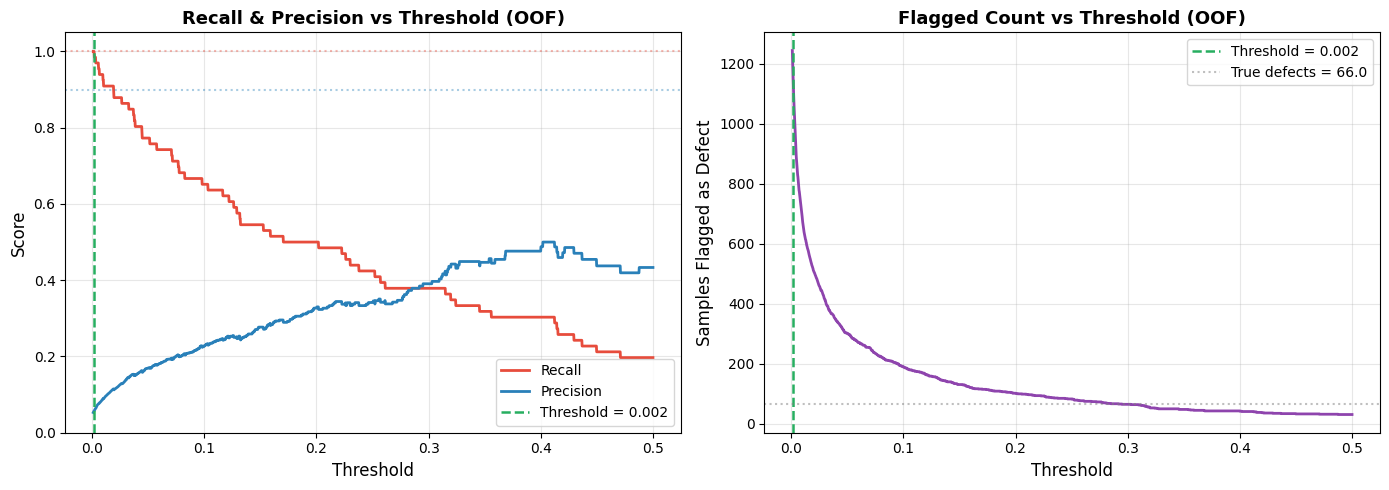

Plot saved: threshold_analysis.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Recall & Precision vs Threshold
ax = axes[0]
ax.plot(results_df['threshold'], results_df['recall'],    label='Recall',    color='#e74c3c', lw=2)
ax.plot(results_df['threshold'], results_df['precision'], label='Precision', color='#2980b9', lw=2)
ax.axvline(OPTIMAL_THRESHOLD, color='#27ae60', linestyle='--', lw=1.8, label=f'Threshold = {OPTIMAL_THRESHOLD:.3f}')
ax.axhline(1.0, color='#e74c3c', linestyle=':', alpha=0.4)
ax.axhline(0.9, color='#2980b9', linestyle=':', alpha=0.4)
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Recall & Precision vs Threshold (OOF)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# Plot 2: Number of flagged samples vs Threshold
ax2 = axes[1]
ax2.plot(results_df['threshold'], results_df['n_flagged'], color='#8e44ad', lw=2)
ax2.axvline(OPTIMAL_THRESHOLD, color='#27ae60', linestyle='--', lw=1.8, label=f'Threshold = {OPTIMAL_THRESHOLD:.3f}')
ax2.axhline(pos_count, color='gray', linestyle=':', alpha=0.5, label=f'True defects = {pos_count}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Samples Flagged as Defect', fontsize=12)
ax2.set_title('Flagged Count vs Threshold (OOF)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: threshold_analysis.png')

## Step 7 — Retrain on Full Training Set

In [10]:
final_test_proba = np.zeros(len(X_test))

for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    final_test_proba += p / len(models)
    print(f'  {name:15s}: retrained  |  test-flagged @{OPTIMAL_THRESHOLD:.3f} = {(p >= OPTIMAL_THRESHOLD).sum()}')

final_preds = (final_test_proba >= OPTIMAL_THRESHOLD).astype(int)
print(f'\n✅ Final defects flagged in test set: {final_preds.sum()} / {len(final_preds)}')

  LightGBM       : retrained  |  test-flagged @0.002 = 81
  XGBoost        : retrained  |  test-flagged @0.002 = 280
  CatBoost       : retrained  |  test-flagged @0.002 = 224
  RandomForest   : retrained  |  test-flagged @0.002 = 285
  ExtraTrees     : retrained  |  test-flagged @0.002 = 298

✅ Final defects flagged in test set: 274 / 339


## Step 8 — Generate Submission CSV

In [11]:
submission = pd.DataFrame({
    'CoilID': test['CoilID'].values,
    'Y'     : final_preds,
})

submission.to_csv('expected_submission.csv', index=False)

print(f'Saved: expected_submission.csv  ({submission.shape[0]} rows × 2 cols)')
print('Class distribution:')
print(submission['Y'].value_counts().to_string())

submission.head(10)

Saved: expected_submission.csv  (339 rows × 2 cols)
Class distribution:
Y
1    274
0     65


,CoilID,Y
0,711,1
1,1542,0
2,1232,1
3,600,0
4,1087,1
5,1401,0
6,217,1
7,877,1
8,1117,1
9,555,0


---
## ✅ Done!

Submit `expected_submission.csv` to the hackathon platform. Good luck! 🏭